# Task01

For this project, we selected the G. Xinhua Square traffic intersection as the main study location. This scene was chosen because it contains relatively little visual noise and only a limited number of occlusions. The road remains clearly visible throughout the video, and vehicles are not heavily blocked by trees or other large objects, except for minor infrastructure elements such as traffic lights. Another advantage of this video is that it gradually transitions from daytime to evening conditions, allowing the model to observe the same location under different lighting conditions.

To prepare the data, we created two separate datasets in order to compare their usefulness for the object detection task. The first dataset was based on the full video extracted at 15.5 frames per second, using the annotations provided by the original dataset author. This resulted in approximately 12,000 images. The second dataset was generated from the same video but extracted at 25 frames per second and annotated manually by us. The full version of this dataset contained approximately 19,500 images.

However, for the manually annotated version, we decided not to use the entire dataset. Instead, we selected a smaller subset of around 1,100 images. The purpose of this comparison was to evaluate whether a smaller but manually verified dataset could outperform a larger dataset with unverified or automatically provided annotations.

The prepared datasets were organized for YOLO-based object detection training. The final data was structured into training, validation, and test subsets, with corresponding image and annotation files stored in the standard YOLO format.

# Task02

For this task, we selected YOLOv11n as the main object detection model. The main reason for this choice was its strong balance between efficiency and performance. Since the project required multiple experiments, including pretrained evaluation, fine-tuning, and sliced inference with SAHI, a lightweight detector was more practical than a heavier model. Compared with Faster R-CNN, YOLO offers a faster and more convenient workflow for training and inference, while Faster R-CNN is usually more computationally expensive. Compared with RetinaNet, YOLO was also easier to integrate into our pipeline and allowed faster experimentation. The nano version was chosen because it could be trained efficiently while still producing meaningful results.

For the dataset provided by the source, we kept the original object classes: car, bus, and truck. For our custom dataset, we decided to keep only car and bus, because during manual inspection of the video we did not observe a meaningful number of trucks. Keeping an unnecessary class would likely introduce noise and reduce class consistency in the training data.

### Pretrained (non fine-tuned)

When we evaluated the pretrained YOLO model directly on our aerial traffic dataset, the results were poor. This was expected because the pretrained model was not adapted to our specific problem setting. Our data uses a top-down aerial viewpoint, contains relatively small vehicles, and shows a scene layout that differs from general-purpose natural image datasets. Because of this mismatch in viewpoint, scale, and object density, the pretrained detector could not perform well without fine-tuning.

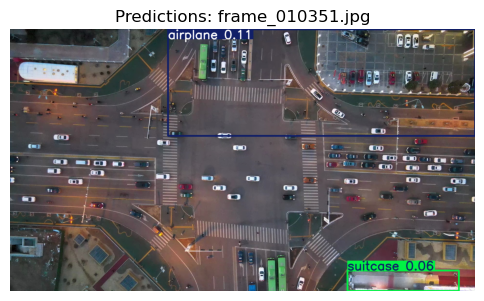

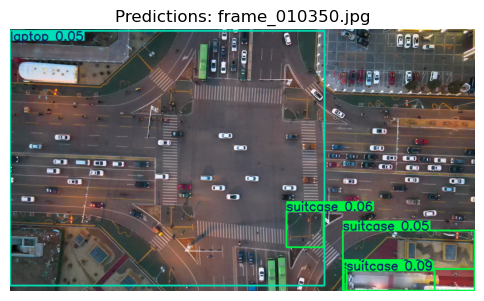

### Pretrained (fine-tuned)

Both fine-tuned models were trained under the same conditions, using the same number of epochs, batch size, and image size. However, the model trained on the custom annotated dataset achieved better overall results. The difference was especially noticeable in the bus class, while the results for cars were more similar. A likely explanation is that the custom dataset had more reliable and consistent annotations. In contrast, the larger provided dataset may have contained noisier or less carefully verified labels. This shows that annotation quality can have a stronger impact on detection performance than dataset size alone.

| Model | Best Precision | Best Recall | Best mAP50 | Best mAP50-95 |
|---|---:|---:|---:|---:|
| YOLO11n fine-tuned prelabelled | 0.9877 | 0.8453 | 0.6440 | 0.4092 |
| YOLO11n fine-tuned custom | 0.9804 | 0.9949 | 0.9883 | 0.8733 |

**Conclusion:** The custom dataset model performed better in both **mAP50** and **mAP50-95**.

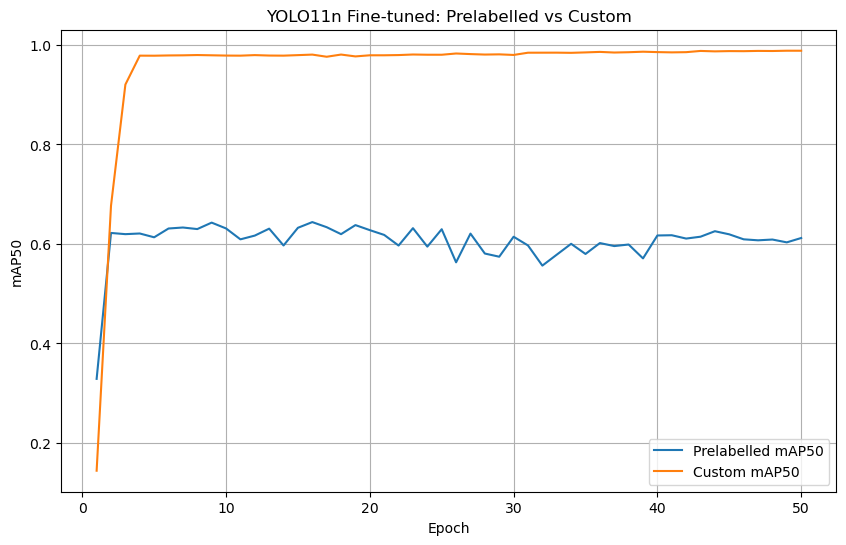

#### YOLO fine-tuned prelabeled

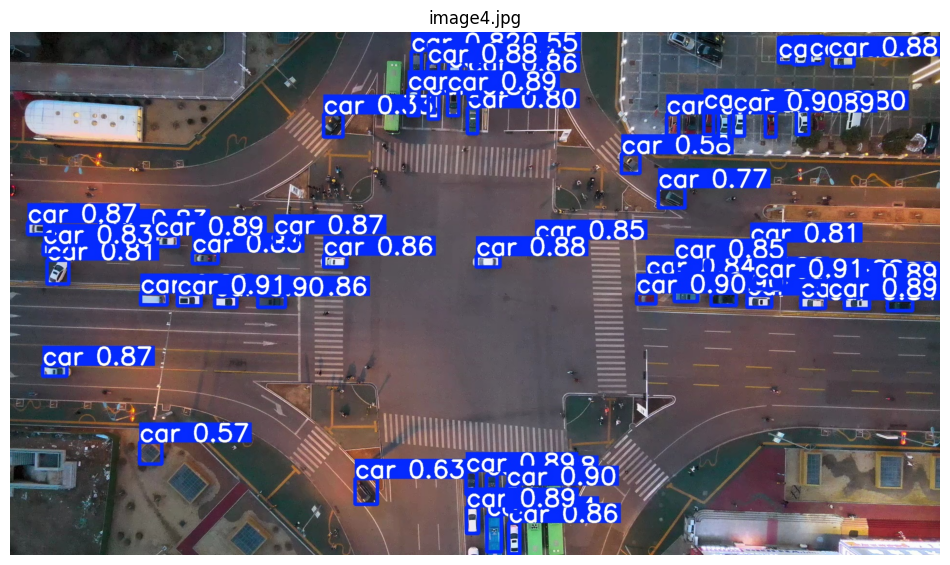

#### YOLO fine-tuned custom

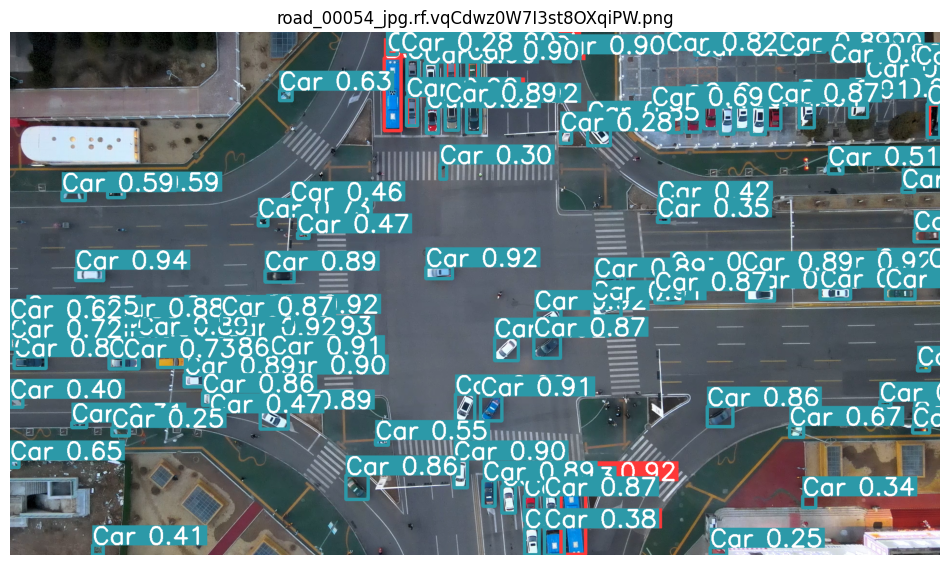

### YOLO + SAHI

We also evaluated an additional advanced variant by applying SAHI to both models. However, the SAHI-based approach did not outperform the standard fine-tuned YOLO model. A likely reason is that the original fine-tuned detector was already able to detect most objects reasonably well at the image scale used in our experiments. In this case, sliced inference did not provide a strong advantage. Furthermore, SAHI can sometimes introduce duplicate detections or small inconsistencies when predictions from multiple image slices are merged, which may slightly reduce the final metrics.

### PreLabeled YOLO + SAHI

| Model | mAP50-95 | mAP50 | Precision@0.5 | Recall@0.5 |
|---|---:|---:|---:|---:|
| Fine-tuned YOLO | 0.356162 | 0.479254 | 0.959892 | 0.965754 |
| Fine-tuned YOLO + SAHI | 0.328915 | 0.477629 | 0.698264 | 0.973716 |

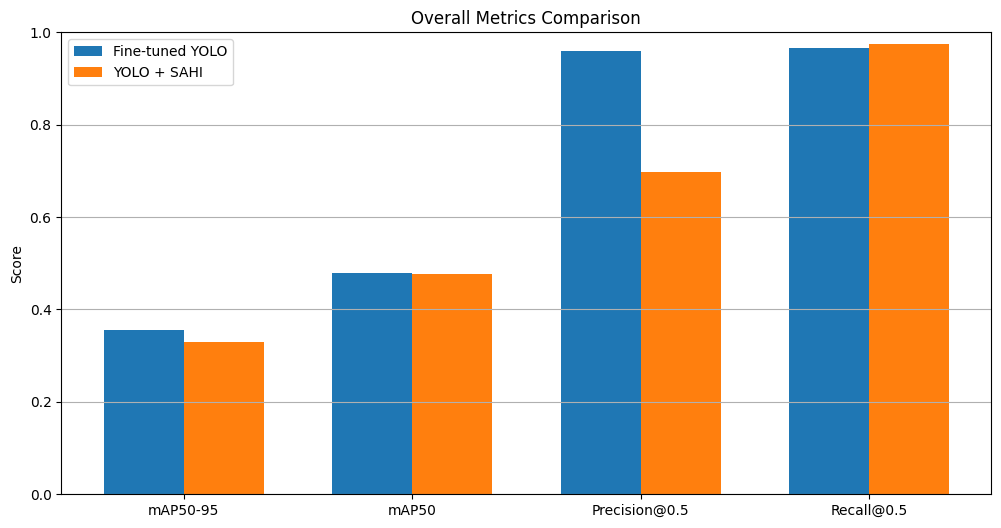

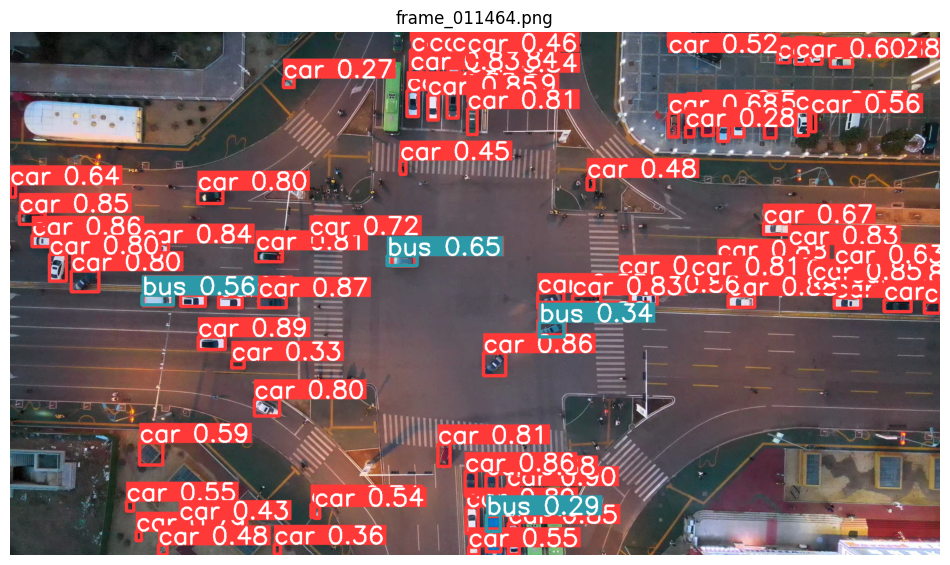

### Custom YOLO + SAHI

| Model | mAP50-95 | mAP50 | Precision@0.5 | Recall@0.5 |
|---|---:|---:|---:|---:|
| Fine-tuned YOLO | 0.893655 | 0.982089 | 0.963721 | 0.997236 |
| Fine-tuned YOLO + SAHI | 0.881748 | 0.978694 | 0.718491 | 0.997812 |

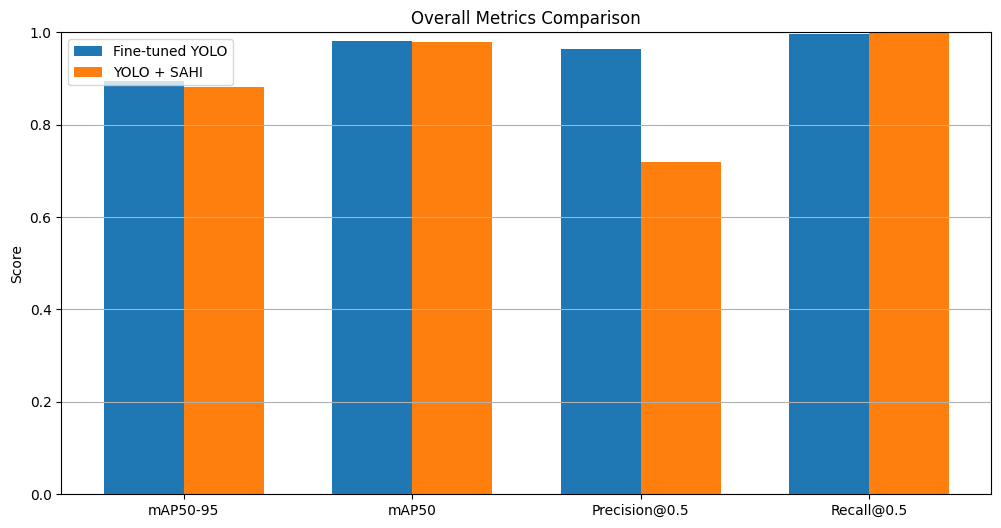

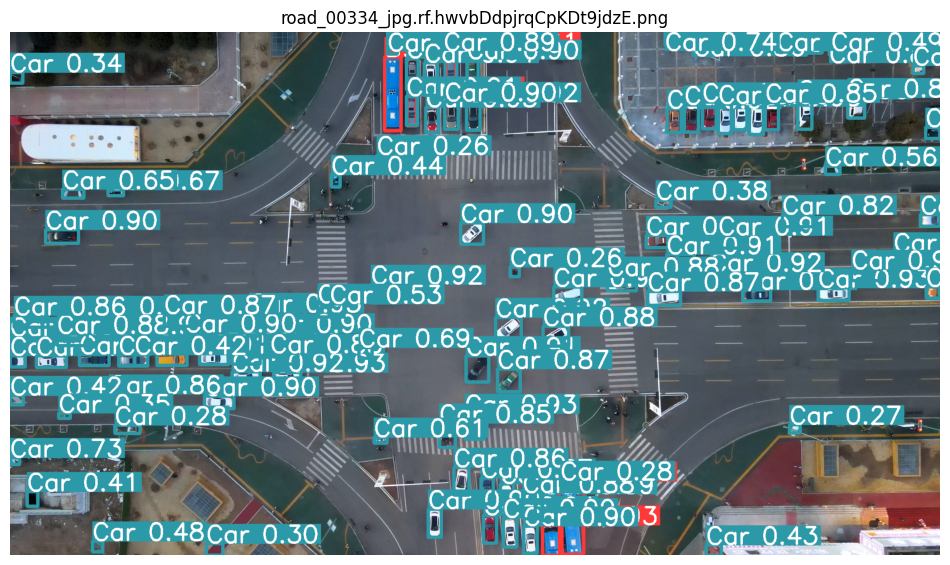

### Conclusion

Overall, the results suggest that a larger dataset does not automatically lead to better performance. In our case, the smaller manually prepared dataset produced more reliable results than the larger dataset with externally provided annotations. This indicates that data quality and annotation consistency are critical factors in object detection performance. It also shows that more complex methods are not always better: a simpler fine-tuned YOLO model performed better overall than the SAHI-based variant on this dataset.

# Task03

For this task, we focused only on the main roads entering the junction and excluded the slip roads, since they were not directly part of the core intersection flow. Vehicle detection was performed using our fine-tuned YOLOv11n model trained on the custom dataset, as this model produced the most reliable detection results in the previous task.

To estimate traffic flow, we used counting lines placed on the main incoming roads and recorded vehicle crossing events. These detections were first converted into per-second counts and then aggregated into 10-second time windows in order to build a cleaner and more stable traffic flow time series. This aggregation reduced noise and made the data more suitable for forecasting. The resulting time series was analyzed both for the total traffic flow and separately for each incoming direction (top, bottom, left, and right).

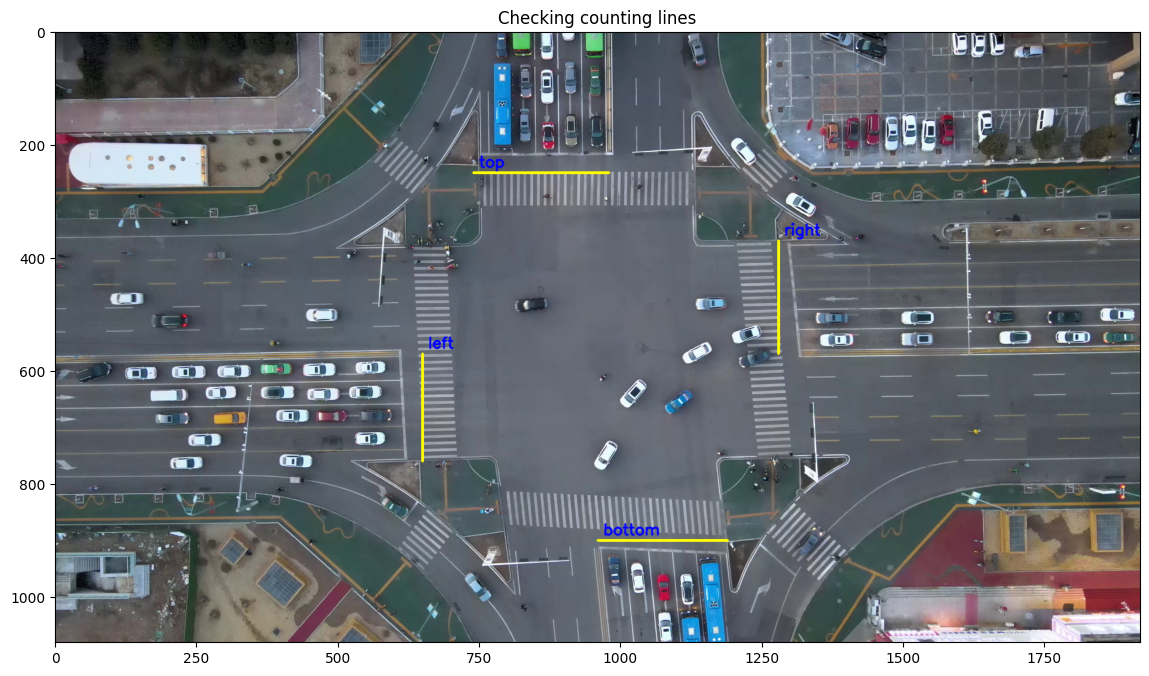

### Prediction on known traffic and unknown traffic

For forecasting, we compared several approaches: a simple baseline model, ARIMA, Prophet, and LSTM. This allowed us to evaluate both traditional statistical forecasting methods and a neural network-based method on the same traffic flow data. Forecasts were generated not only on the original observed video timeline, but also on the held-out future part of the sequence, allowing us to assess how well each model could predict upcoming traffic flow beyond the observed training segment.

### Known traffic

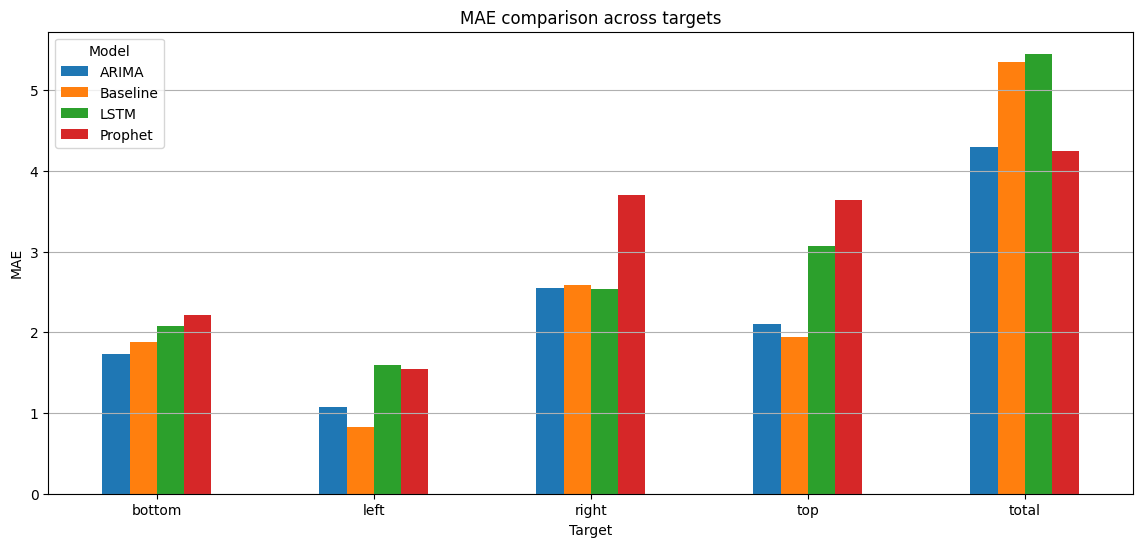

### Unknown traffic

| horizon | model | mean_forecast | max_forecast | min_forecast |
|---|---|---:|---:|---:|
| 1_hour | ARIMA | 2.308 | 2.832 | 0.300 |
| 1_hour | Baseline | 0.250 | 0.250 | 0.250 |
| 1_hour | LSTM | 3.427 | 6.853 | 0.666 |
| 1_hour | Prophet | 0.851 | 2.638 | 0.138 |
| 2_hours | ARIMA | 2.312 | 2.832 | 0.300 |
| 2_hours | Baseline | 0.250 | 0.250 | 0.250 |
| 2_hours | LSTM | 3.742 | 8.612 | 0.664 |
| 2_hours | Prophet | 0.430 | 2.638 | 0.000 |
| 30_minutes | ARIMA | 2.298 | 2.832 | 0.300 |
| 30_minutes | Baseline | 0.250 | 0.250 | 0.250 |
| 30_minutes | LSTM | 3.543 | 7.725 | 0.508 |
| 30_minutes | Prophet | 1.296 | 2.638 | 0.677 |



When we evaluated forecasting on the part of the traffic flow that was still known to us, we observed that different models performed better for different directions. This is reasonable because each incoming road had its own traffic pattern. Some directions were sparse and contained many zero values, some were more stable, and others showed sharper fluctuations. Because of this, no single model was best for every case.

For unknown future traffic, no model can be declared definitively best without real future observations. However, the models showed clearly different behaviors. The baseline was stable but too simple, since it only repeated the last observed value. Prophet often pushed forecasts toward very small values or zero, suggesting that it oversmoothed the series. LSTM produced the most dynamic forecasts, but also showed strong oscillations and unrealistic peaks, likely because the traffic series was too short and irregular for stable neural forecasting. Among these approaches, ARIMA produced the most balanced and interpretable forecasts, so in this project it appeared to be the most reliable model for unknown future traffic.

# Task04


# Task05

For this task, we used a genetic algorithm to optimize the traffic light schedule based on the traffic flows obtained in the previous step. We compared the optimized strategy with a simple fixed timing baseline and showed that the optimized version reduced total waiting time and queue length.

We made this task more advanced by optimizing not just one green-light duration, but a full signal plan including vertical green time, horizontal green time, yellow time, all-red time, and phase ordering. This made the problem more realistic and closer to an actual traffic signal control scenario.

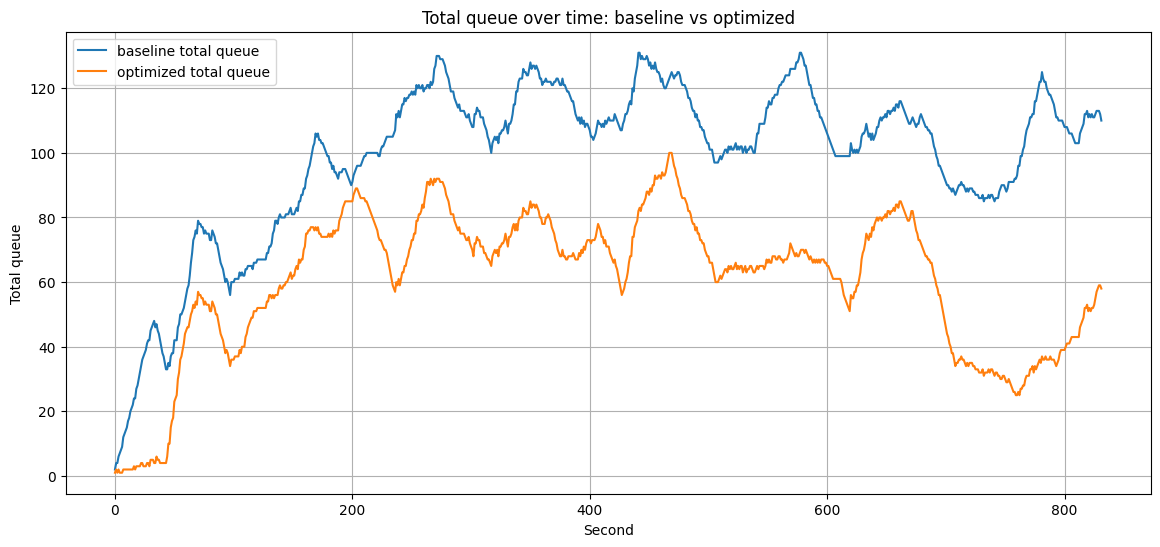

The optimized solution achieved a clear improvement over the fixed baseline. The total waiting time decreased from 82,308 to 50,281, which corresponds to an improvement of about 38.9%. The maximum total queue length was reduced from 131 to 100, an improvement of about 23.7%. The overall fitness value also improved by about 38.9%, showing that the optimized schedule was substantially more effective than the original fixed strategy.

The best signal plan found by the algorithm used the following settings: 39 seconds of green for the vertical direction, 57 seconds of green for the horizontal direction, 2 seconds of yellow, 0 seconds of all-red, and horizontal-first phase ordering. This result suggests that, for the observed traffic pattern, the horizontal flow required more capacity than the vertical one. The optimization process was illustrated using convergence plots, queue evolution plots, and a direct comparison between the baseline and optimized strategies.